## 제외 칼럼
- transaction_id
- user_id
- addiction_level

num_features = [
    'age','daily_screen_time_hours','social_medai_hours','gaming_hours',
    'work_study_hours','sleep_hours','notifications_per_day','app_opens_per_day','weekend_screen_time'
]
onehot_features = ['gender']
binary_features = ['academic_work_impact']

num_features에 대해서 다양한 scaling 적용 후 성능 평가

첫번째는 모든 feature에 대해서 standard scaling 적용


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

Mounted at /content/drive


In [6]:
df = df.drop(columns=['transaction_id', 'user_id', 'addiction_level'])
print(df.columns)
X = df.drop(columns=['addicted_label'])
y = df['addicted_label']

Index(['age', 'gender', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')


In [8]:
num_features = [
    'age','daily_screen_time_hours','social_media_hours','gaming_hours',
    'work_study_hours','sleep_hours','notifications_per_day','app_opens_per_day','weekend_screen_time'
]
onehot_features = ['gender']
binary_features = ['academic_work_impact']

X = df[num_features + onehot_features + binary_features]
y = df['addicted_label']

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler


preprocessor = ColumnTransformer(
    transformers=[
        ('num',RobustScaler(), num_features),
        ('gender', OneHotEncoder(handle_unknown='ignore'),onehot_features),
        ('impact', OrdinalEncoder(categories=[['No', 'Yes']]), binary_features)
    ]
)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        # C=C
        # class_weight = cw
        max_iter=1000
    ))
])

# 5-fold cross validation 예측값 생성
y_pred = cross_val_predict(
    model,
    X,
    y,
    cv=cv
)

print("Accuracy:", accuracy_score(y, y_pred))
print("Precision:", precision_score(y, y_pred))
print("Recall:", recall_score(y, y_pred))
print("F1-score:", f1_score(y, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

Accuracy: 0.8909333333333334
Precision: 0.9128356013240162
Recall: 0.9351921627731725
F1-score: 0.9238786525218686

Confusion Matrix:
[[1718  474]
 [ 344 4964]]


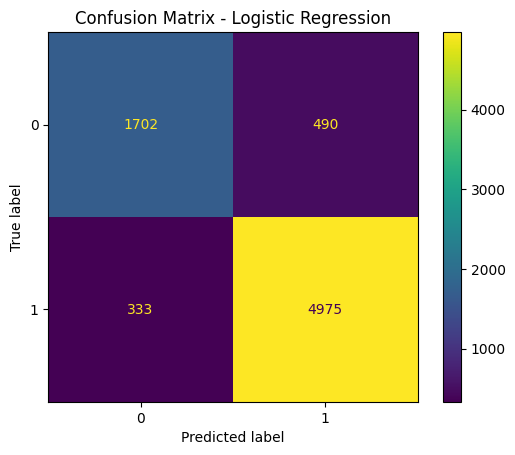

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['0', '1']
)

disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()